# 10 — Agent-Ready Triage Interpretation

This notebook demonstrates how the **A1 agent adapter layer** converts
deterministic triage results into compact, JSON-serialisable payloads
suitable for agentic consumers, chat interfaces, and API integrations.

## What this notebook covers

1. Running a deterministic triage and inspecting the raw `TriageResult`
2. Serialising results to a `TriageAgentPayload` using factory functions
3. Inspecting payload structure and warning fields
4. Comparing raw deterministic output vs agent-friendly narrative
5. Batch mode: per-series F7 payloads

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import numpy as np

os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt

from forecastability.adapters.agents.triage_agent_payload_models import (
    F1ProfilePayload,
    F7BatchRankPayload,
    TriageAgentPayload,
    f1_profile_payload,
    f2_limits_payload,
    f6_complexity_payload,
    f7_batch_rank_payload,
    triage_agent_payload,
)
from forecastability.triage.batch_models import BatchSeriesRequest, BatchTriageRequest
from forecastability.triage.models import AnalysisGoal, TriageRequest
from forecastability.triage.run_batch_triage import run_batch_triage
from forecastability.triage.run_triage import run_triage

Path("outputs/figures/agent").mkdir(parents=True, exist_ok=True)
Path("outputs/json").mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## Section 1 — Run deterministic triage

We run `run_triage()` on a seasonal synthetic series and inspect the raw `TriageResult`.
The result contains deterministic numerical outputs — no narrative, no agent logic.

In [2]:
rng = np.random.default_rng(42)
t = np.arange(600)
series = (
    np.sin(2 * np.pi * t / 12)
    + 0.5 * np.sin(2 * np.pi * t / 6)
    + 0.2 * rng.standard_normal(600)
)

request = TriageRequest(series=series, max_lag=20, n_surrogates=99, random_state=42)
result = run_triage(request)

print(f"Blocked: {result.blocked}")
print(f"Readiness: {result.readiness.status}")
if result.interpretation:
    print(f"Forecastability class: {result.interpretation.forecastability_class}")
    print(f"Directness class: {result.interpretation.directness_class}")
    print(f"Modeling regime: {result.interpretation.modeling_regime}")
if result.forecastability_profile:
    print(f"Peak horizon: {result.forecastability_profile.peak_horizon}")
    print(f"Informative horizons: {result.forecastability_profile.informative_horizons}")
if result.complexity_band:
    print(f"Complexity band: {result.complexity_band.complexity_band}")

Blocked: False
Readiness: clear
Forecastability class: high
Directness class: low
Modeling regime: compact_structured_models
Peak horizon: 12
Informative horizons: [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 17, 18, 19, 20]
Complexity band: medium


## Section 2 — Convert to agent-ready payload

The `triage_agent_payload()` factory converts a full `TriageResult` into a
`TriageAgentPayload` — a flat, JSON-serialisable Pydantic model that:

- replaces `numpy` arrays with Python lists
- surfaces warnings explicitly
- marks experimental components
- includes a schema version for forward compatibility

In [3]:
payload = triage_agent_payload(result, series_id="seasonal_synthetic")

print(f"schema_version: {payload.schema_version}")
print(f"series_id: {payload.series_id}")
print(f"blocked: {payload.blocked}")
print(f"readiness_status: {payload.readiness_status}")
print(f"forecastability_class: {payload.forecastability_class}")
print(f"directness_class: {payload.directness_class}")
print(f"modeling_regime: {payload.modeling_regime}")
print(f"warnings: {payload.warnings}")
print(f"experimental_notes: {payload.experimental_notes}")

schema_version: 1
series_id: seasonal_synthetic
blocked: False
readiness_status: clear
forecastability_class: high
directness_class: low
modeling_regime: compact_structured_models
warnings: []
experimental_notes: ['EXPERIMENTAL — LLE unreliable: n=600 is below the recommended minimum of 10^m=1000 for m=3. Do not use as a sole triage decision-maker.']


In [4]:
if payload.f1_profile:
    print("=== F1 Profile Payload ===")
    print(f"profile_shape_label: {payload.f1_profile.profile_shape_label}")
    print(f"peak_horizon: {payload.f1_profile.peak_horizon}")
    print(f"informative_horizons: {payload.f1_profile.informative_horizons}")
    print(f"model_now: {payload.f1_profile.model_now}")
    print(f"review_horizons: {payload.f1_profile.review_horizons}")

if payload.f2_limits:
    print("\n=== F2 Limits Payload ===")
    print(f"ceiling_summary: {payload.f2_limits.ceiling_summary}")
    print(f"compression_warning: {payload.f2_limits.compression_warning}")
    print(f"dpi_warning: {payload.f2_limits.dpi_warning}")

if payload.f6_complexity:
    print("\n=== F6 Complexity Payload ===")
    print(f"complexity_band: {payload.f6_complexity.complexity_band}")
    print(f"permutation_entropy: {payload.f6_complexity.permutation_entropy:.4f}")
    print(f"spectral_entropy: {payload.f6_complexity.spectral_entropy:.4f}")

=== F1 Profile Payload ===
profile_shape_label: non_monotone
peak_horizon: 12
informative_horizons: [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 17, 18, 19, 20]
model_now: HIGH — Complex structured models recommended for 17 informative horizon(s).
review_horizons: [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 17, 18, 19, 20]

=== F2 Limits Payload ===
ceiling_summary: Peak MI=1.1032 at horizon 12; 20 horizon(s) exceed the non-trivial threshold (0.01).

=== F6 Complexity Payload ===
complexity_band: medium
permutation_entropy: 0.7519
spectral_entropy: 0.3664


## Section 3 — JSON serialisation

The payload is fully JSON-serialisable — no numpy types, no domain objects.
This is the format an agent, API endpoint, or chat backend would receive.

In [5]:
payload_dict = json.loads(payload.model_dump_json())
print(json.dumps(payload_dict, indent=2))

{
  "schema_version": "1",
  "series_id": "seasonal_synthetic",
  "blocked": false,
  "readiness_status": "clear",
  "forecastability_class": "high",
  "directness_class": "low",
  "modeling_regime": "compact_structured_models",
  "recommendation": "HIGH -> Complex structured models (deep AR, nonlinear, LSTM)",
  "f1_profile": {
    "schema_version": "1",
    "peak_horizon": 12,
    "informative_horizons": [
      1,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      11,
      12,
      13,
      15,
      16,
      17,
      18,
      19,
      20
    ],
    "profile_shape_label": "non_monotone",
    "profile_summary": "Peak forecastability at horizon 12, 17 informative horizon(s) identified.",
    "model_now": "HIGH \u2014 Complex structured models recommended for 17 informative horizon(s).",
    "review_horizons": [
      1,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      11,
      12,
      13,
      15,
      16,
      17,
      18,
      19,

## Section 4 — Deterministic fields vs agent-friendly narrative

The payload preserves all deterministic fields exactly.
An agent layer can then compose these into a narrative — but the narrative
adds NO new science: it only reformats deterministic outputs.

Here we show the contrast between raw payload fields and a simple
rule-based narrative built entirely from those fields.

In [6]:
def _build_simple_narrative(p: TriageAgentPayload) -> str:
    """Build a simple rule-based narrative from a TriageAgentPayload.

    This demonstrates how agents consume deterministic fields — no LLM required.

    Args:
        p: TriageAgentPayload to narrate.

    Returns:
        Plain-English summary string derived entirely from payload fields.
    """
    if p.blocked:
        return f"Analysis blocked at readiness gate (status: {p.readiness_status})."

    lines: list[str] = []
    lines.append(f"Series '{p.series_id or 'unnamed'}' analysis complete.")

    if p.forecastability_class:
        lines.append(
            f"Forecastability: {p.forecastability_class}"
            f" ({p.modeling_regime or 'regime unknown'})."
        )

    if p.f1_profile:
        n_inf = len(p.f1_profile.informative_horizons)
        lines.append(
            f"Profile: {p.f1_profile.profile_shape_label}, {n_inf} informative horizon(s),"
            f" peak at h={p.f1_profile.peak_horizon}."
        )

    if p.f6_complexity:
        lines.append(
            f"Complexity: {p.f6_complexity.complexity_band} band"
            f" (PE={p.f6_complexity.permutation_entropy:.3f})."
        )

    if p.warnings:
        lines.append(f"Warnings: {'; '.join(p.warnings)}")

    return " ".join(lines)


narrative = _build_simple_narrative(payload)
print("=== Rule-based narrative from deterministic fields ===")
print(narrative)
print()
print("=== Note: all values above are derived from deterministic payload fields ===")
print("=== No LLM or additional inference was performed ===")

=== Rule-based narrative from deterministic fields ===
Series 'seasonal_synthetic' analysis complete. Forecastability: high (compact_structured_models). Profile: non_monotone, 17 informative horizon(s), peak at h=12. Complexity: medium band (PE=0.752).

=== Note: all values above are derived from deterministic payload fields ===
=== No LLM or additional inference was performed ===


## Section 5 — Batch mode: F7 per-series payloads

When running batch triage, each series result maps to an `F7BatchRankPayload`.

In [7]:
rng_b = np.random.default_rng(99)
n_b = 400


def _ar1(phi: float, n: int, seed: int) -> list[float]:
    """Generate AR(1) series as a Python list.

    Args:
        phi: Autoregressive coefficient.
        n: Number of observations.
        seed: Random seed.

    Returns:
        List of floats of length n.
    """
    rng_i = np.random.default_rng(seed)
    s = np.zeros(n)
    s[0] = rng_i.standard_normal()
    for i in range(1, n):
        s[i] = phi * s[i - 1] + rng_i.standard_normal()
    return s.tolist()


batch_request = BatchTriageRequest(
    items=[
        BatchSeriesRequest(series_id="high_ar1", series=_ar1(0.92, n_b, 10)),
        BatchSeriesRequest(series_id="medium_ar1", series=_ar1(0.55, n_b, 20)),
        BatchSeriesRequest(series_id="low_ar1", series=_ar1(0.15, n_b, 30)),
        BatchSeriesRequest(series_id="white_noise", series=rng_b.standard_normal(n_b).tolist()),
        BatchSeriesRequest(
            series_id="seasonal",
            series=(
                np.sin(2 * np.pi * np.arange(n_b) / 12)
                + 0.3 * rng_b.standard_normal(n_b)
            ).tolist(),
        ),
    ],
    max_lag=20,
    n_surrogates=99,
    random_state=42,
)

batch_response = run_batch_triage(batch_request)
f7_payloads = [f7_batch_rank_payload(item) for item in batch_response.items]

print(f"{'Rank':<6} {'Series ID':<15} {'Outcome':<10} {'F-Class':<12} {'Complexity':<12} {'Summary'}")
print("-" * 80)
for p in f7_payloads:
    print(
        f"{str(p.batch_rank):<6} {p.series_id:<15} {p.outcome:<10} "
        f"{str(p.forecastability_class or '-'):<12} {str(p.complexity_band or '-'):<12} "
        f"{p.ranking_summary[:40]}"
    )

Rank   Series ID       Outcome    F-Class      Complexity   Summary
--------------------------------------------------------------------------------
1      medium_ar1      ok         high         high         Rank 1: medium_ar1 — high, ok
2      high_ar1        ok         high         high         Rank 2: high_ar1 — high, ok
3      seasonal        ok         high         medium       Rank 3: seasonal — high, ok
4      low_ar1         ok         low          high         Rank 4: low_ar1 — low, ok
5      white_noise     ok         low          high         Rank 5: white_noise — low, ok


## Section 6 — Visualisation

A summary figure comparing raw AMI values against the payload's informative-horizon classification.

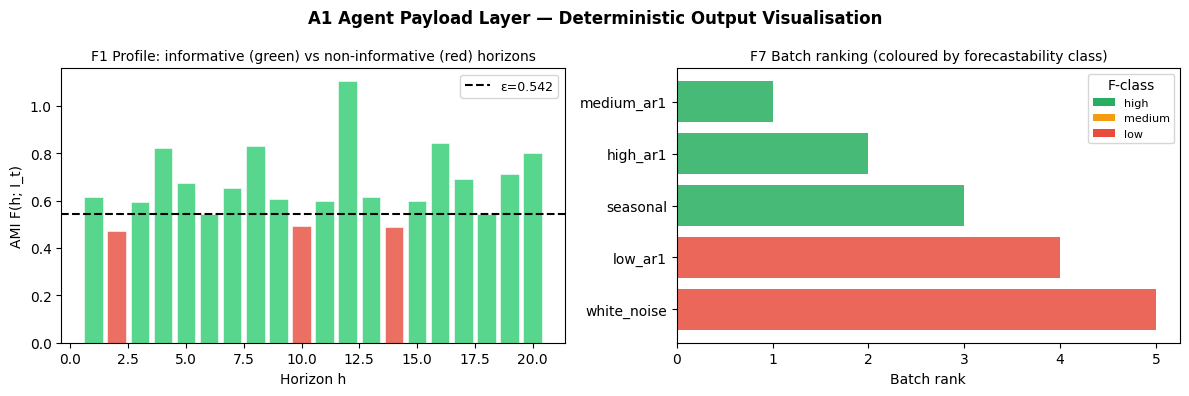

Figure saved.


In [8]:
from matplotlib.patches import Patch

Path("outputs/figures/agent").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: AMI profile + payload informative horizons
if result.forecastability_profile is not None and payload.f1_profile is not None:
    profile = result.forecastability_profile
    p1 = payload.f1_profile
    axes[0].bar(
        profile.horizons,
        profile.values.tolist(),
        color=[
            "#2ecc71" if h in p1.informative_horizons else "#e74c3c"
            for h in profile.horizons
        ],
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )
    axes[0].axhline(
        y=profile.epsilon,
        color="black",
        linestyle="--",
        lw=1.5,
        label=f"ε={profile.epsilon:.3f}",
    )
    axes[0].set_title(
        "F1 Profile: informative (green) vs non-informative (red) horizons",
        fontsize=10,
    )
    axes[0].set_xlabel("Horizon h")
    axes[0].set_ylabel("AMI F(h; I_t)")
    axes[0].legend(fontsize=9)
else:
    axes[0].text(0.5, 0.5, "No profile data", ha="center", va="center",
                 transform=axes[0].transAxes)
    axes[0].set_title("F1 Profile")

# Right: F7 batch ranking coloured by forecastability class
ok_items = [p for p in f7_payloads if p.outcome == "ok" and p.batch_rank is not None]
color_map: dict[str | None, str] = {
    "high": "#27ae60",
    "medium": "#f39c12",
    "low": "#e74c3c",
    None: "#95a5a6",
}
colors = [color_map.get(p.forecastability_class, "#95a5a6") for p in ok_items]
labels = [p.series_id for p in ok_items]
ranks = [p.batch_rank for p in ok_items]

if ok_items:
    axes[1].barh(labels, ranks, color=colors, alpha=0.85)
    axes[1].set_xlabel("Batch rank")
    axes[1].set_title("F7 Batch ranking (coloured by forecastability class)", fontsize=10)
    axes[1].invert_yaxis()
    legend_elements = [
        Patch(facecolor="#27ae60", label="high"),
        Patch(facecolor="#f39c12", label="medium"),
        Patch(facecolor="#e74c3c", label="low"),
    ]
    axes[1].legend(handles=legend_elements, title="F-class", fontsize=8)
else:
    axes[1].text(0.5, 0.5, "No ok items", ha="center", va="center",
                 transform=axes[1].transAxes)
    axes[1].set_title("F7 Batch ranking")

fig.suptitle(
    "A1 Agent Payload Layer — Deterministic Output Visualisation",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("outputs/figures/agent/a1_payload_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Summary

This notebook demonstrated the A1 agent adapter layer:

| Component | Purpose |
|---|---|
| `TriageAgentPayload` | Top-level JSON-serialisable payload from `TriageResult` |
| `F1ProfilePayload` | Profile shape, informative horizons, recommendations |
| `F2LimitsPayload` | Theoretical ceiling, compression and DPI warnings |
| `F6ComplexityPayload` | Permutation entropy, spectral entropy, complexity band |
| `F7BatchRankPayload` | Per-series batch rank, outcome, diagnostic vector |
| `triage_agent_payload()` | Factory: `TriageResult` → `TriageAgentPayload` |

**Key design rule**: The adapter adds no new science. All fields are derived
from deterministic domain results. The narrative is built from fields — not
from an LLM or model inference.

> [!NOTE]
> F3/F4 payloads (`F3LearningCurvePayload`, `F4SpectralPayload`) are available
> as standalone factories but are not embedded in `TriageAgentPayload` because
> `TriageResult` does not carry those sub-results by default.